In [145]:
import polars as pl
from scipy.optimize import curve_fit
import numpy as np
import math
import matplotlib.pyplot as plt

In [146]:
def power_law(x, k, a):
    return k * x**a

In [147]:
DATA_FILEPATH = "../data/isoflops_curves.json"
df = pl.read_json(DATA_FILEPATH)
df.head()

parameters,compute_budget,final_loss
i64,f64,f64
49999999,6.0000e18,7.192785
78730505,6.0000e18,6.750171
123969849,6.0000e18,6.40664
195204177,6.0000e18,6.154369
307370470,6.0000e18,5.987783


In [148]:
df = df.with_columns(
    (pl.col("compute_budget") / (6 * pl.col("parameters"))).alias("num_tokens")
)
df.head()

parameters,compute_budget,final_loss,num_tokens
i64,f64,f64,f64
49999999,6.0000e18,7.192785,2.0000e10
78730505,6.0000e18,6.750171,1.2702e10
123969849,6.0000e18,6.40664,8.0665e9
195204177,6.0000e18,6.154369,5.1228e9
307370470,6.0000e18,5.987783,3.2534e9


In [149]:
opt_df = (
    df.group_by("compute_budget")
        .agg(
            pl.all().sort_by("final_loss").first()
        )
    .sort("compute_budget")
)
opt_df

compute_budget,parameters,final_loss,num_tokens
f64,i64,f64,f64
6.0000e18,762093419,5.89993,1.3122e9
1.0000e19,806647749,5.617943,2.0662e9
3.0000e19,1536852354,5.107177,3.2534e9
6.0000e19,1952041776,4.830586,5.1228e9
1.0000e20,3253402960,4.652893,5.1228e9
3.0000e20,5903836027,4.311219,8.4691e9
6.0000e20,6971055968,4.121241,1.4345e10
1.0000e21,6859328563,4.002835,2.4298e10
3.0000e21,12148905329,3.773188,4.1156e10


In [150]:
C = opt_df["compute_budget"].to_numpy()
N = opt_df["parameters"].to_numpy()
D = opt_df["num_tokens"].to_numpy()

In [ ]:
(kN, aN), _ = curve_fit(power_law, C, N)
(kD, aD), _ = curve_fit(power_law, C, D)

In [168]:
C_new = [1e23, 1e24]
N_pred = power_law(C_new, kN, aN)
D_pred = power_law(C_new, kD, aD)

for i, C_cur in enumerate(C_new):
    print(f"C = {C_cur} FLOPs\npredicted optimal model size = {N_pred[i] / 1e9:.3f}B parameters\npredicted optimal dataset size = {D_pred[i]/ 1e9:.3f}B tokens\n")

C = 1e+23 FLOPs
predicted optimal model size = 50.022B parameters
predicted optimal dataset size = 337.016B tokens

C = 1e+24 FLOPs
predicted optimal model size = 126.758B parameters
predicted optimal dataset size = 1331.745B tokens



In [165]:
C_points = np.logspace(np.log10(C.min()), math.log10(max(C_new)))

In [160]:
def plot_power_law(C_points, y, k, a, loglog: bool = False, ylabel: str | None = None, line_label: str | None = None):
    plot_fn = plt.loglog if loglog else plt.plot 
    plot_fn(C, y, 'o')
    plot_fn(C_points, power_law(C_points, k, a), label=line_label)
    plt.xlabel("Compute Budget (FLOPs)")
    if ylabel:
        plt.ylabel(ylabel)
    plt.legend()
    plt.show()


def plot_power_law_N(loglog: bool = False):
    plt.title("Parameters vs Compute Budget")
    plot_power_law(C_points, N, kN, aN, ylabel="Optimal model size (parameters)", line_label=f"N = {kN:.3f}*C^{aN:.3f}", loglog=loglog)


def plot_power_law_D(loglog: bool = False):
    plt.title("Dataset Size vs Compute Budget")
    plot_power_law(C_points, D, kD, aD, ylabel="Optimal dataset size (tokens)", line_label=f"D = {kD:.3f}*C^{aD:.3f}", loglog=loglog)

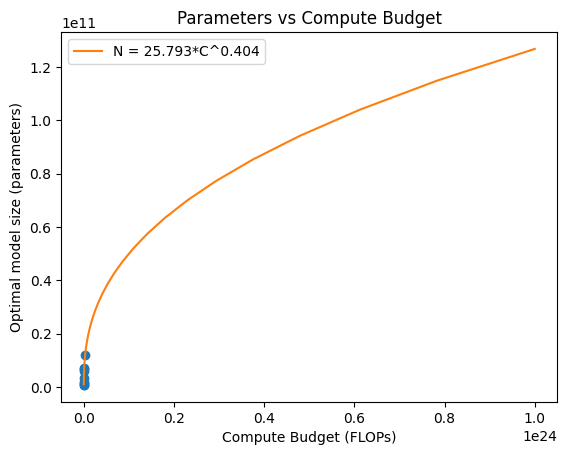

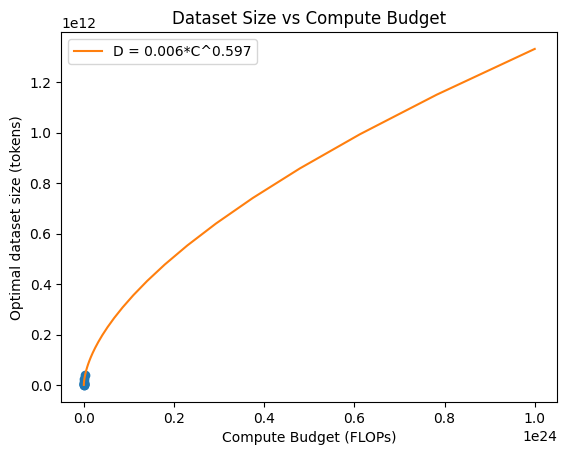

In [161]:
plot_power_law_N()
plot_power_law_D()

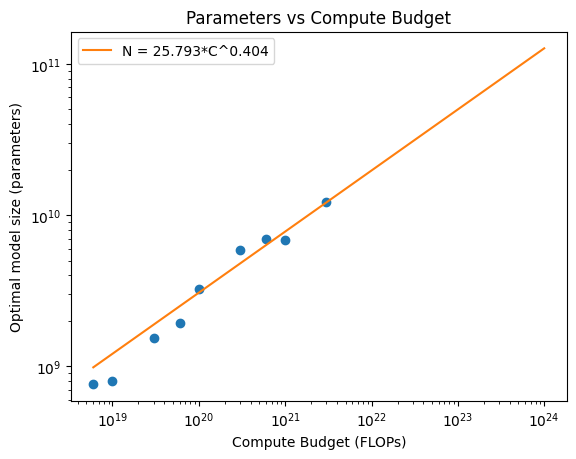

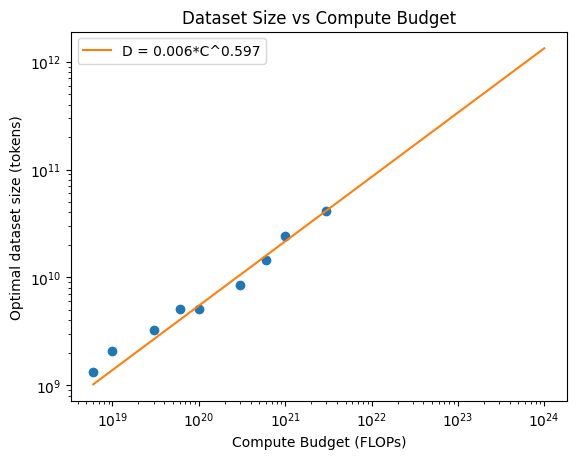

In [162]:
plot_power_law_N(loglog=True)
plot_power_law_D(loglog=True)